# Transfer Learning ile Hurma Çeşitlerinin Sınıflandırılması

Bu proje, "Date Fruit Image Dataset" veri setini kullanarak dokuz farklı hurma çeşidini (Ajwa, Medjool, Nabtat Ali..) sınıflandırmayı amaçlamaktadır. 

- Özel Derin CNN Modeli (Custom Deep CNN): Sıfırdan tasarlanan, en az 5 konvolüsyonel ve 3 havuzlama katmanı içeren, düzenlileştirme (regularization) teknikleriyle güçlendirilmiş bir model.

In [1]:
ls '/kaggle/input/date-fruit-image-dataset-in-controlled-environment'

 Ajwa/     Medjool/  'Nabtat Ali'/   Shaishe/   Sugaey/
 Galaxy/   Meneifi/   Rutab/         Sokari/


In [2]:
# pip install -q protobuf==3.20.3

In [3]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import confusion_matrix
import seaborn as sns
import os.path
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img,img_to_array
import random
import matplotlib.gridspec as gridspec
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')
print("tf versiyon:", tf.__version__)

2025-12-05 06:00:08.257283: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764914408.419664     129 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764914408.467350     129 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


tf versiyon: 2.18.0


In [4]:
#Dosya yolu ve etiketlerden dataframe oluşturma fonksiyonu
def create_dataset(folders,path):
    data = {'imgpath': [], 'labels': []}
    for folder in folders:
        folderpath = os.path.join(path, folder)
        files = os.listdir(folderpath)
        
        for file in files:
            filepath = os.path.join(folderpath, file)
            data['imgpath'].append(filepath)
            data['labels'].append(folder)

    dataset = pd.DataFrame(data)
    return dataset

In [5]:
# Veri seti yollarını tanımlayalım
path = '/kaggle/input/date-fruit-image-dataset-in-controlled-environment'
folders = ['Ajwa','Medjool', 'Nabtat Ali', 'Shaishe','Sugaey','Galaxy', 'Meneifi','Rutab','Sokari']

In [6]:
df=create_dataset(folders,path)

### Keşifsel Veri Analizi (EDA - Exploratory Data Analysis)

In [7]:
df.head()

,imgpath,labels
0,/kaggle/input/date-fruit-image-dataset-in-cont...,Ajwa
1,/kaggle/input/date-fruit-image-dataset-in-cont...,Ajwa
2,/kaggle/input/date-fruit-image-dataset-in-cont...,Ajwa
3,/kaggle/input/date-fruit-image-dataset-in-cont...,Ajwa
4,/kaggle/input/date-fruit-image-dataset-in-cont...,Ajwa


In [8]:
df.shape

(1658, 2)

In [9]:
len(df.labels.unique())

9

In [10]:
df

,imgpath,labels
0,/kaggle/input/date-fruit-image-dataset-in-cont...,Ajwa
1,/kaggle/input/date-fruit-image-dataset-in-cont...,Ajwa
2,/kaggle/input/date-fruit-image-dataset-in-cont...,Ajwa
3,/kaggle/input/date-fruit-image-dataset-in-cont...,Ajwa
4,/kaggle/input/date-fruit-image-dataset-in-cont...,Ajwa
...,...,...
1653,/kaggle/input/date-fruit-image-dataset-in-cont...,Sokari
1654,/kaggle/input/date-fruit-image-dataset-in-cont...,Sokari
1655,/kaggle/input/date-fruit-image-dataset-in-cont...,Sokari
1656,/kaggle/input/date-fruit-image-dataset-in-cont...,Sokari


In [11]:
df.labels.unique()

array(['Ajwa', 'Medjool', 'Nabtat Ali', 'Shaishe', 'Sugaey', 'Galaxy',
       'Meneifi', 'Rutab', 'Sokari'], dtype=object)

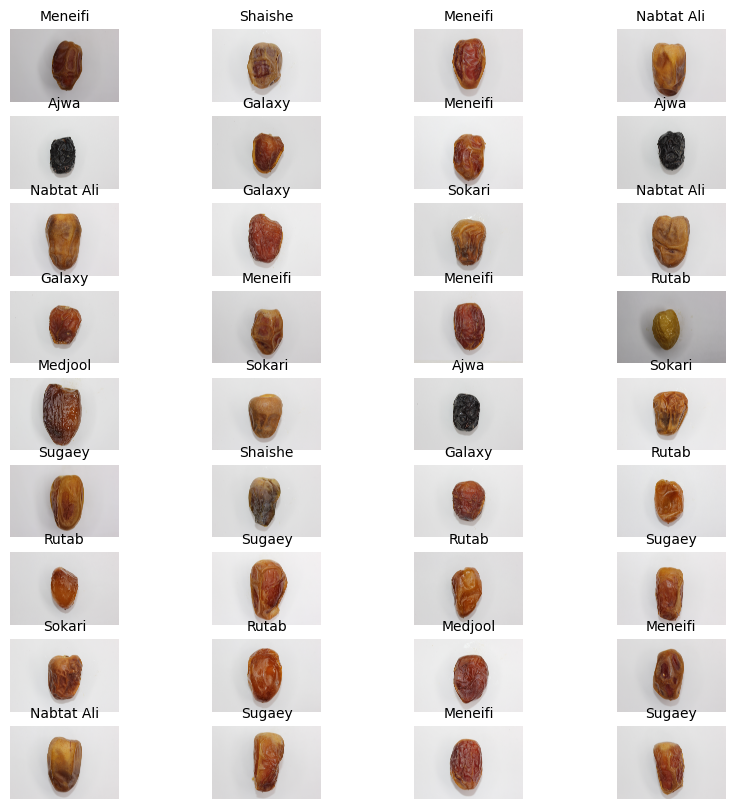

In [12]:
rows = 9
cols = 4
selected_indices = random.sample(range(len(df)), rows * cols)

fig, axes = plt.subplots(rows, cols, figsize = (10, 10))
gs = gridspec.GridSpec(rows, cols, wspace = 0.0, hspace = 0.0)

for i, idx in enumerate(selected_indices):
    row = i // cols
    col = i % cols
    img_path = df['imgpath'].iloc[idx]
    label = df['labels'].iloc[idx]
    img = Image.open(img_path)
    axes[row, col].imshow(img)
    axes[row, col].axis('off')
    axes[row, col].set_title(label, fontsize = 10)

plt.show()

In [13]:
# Veri setini etiketlere göre bölme
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['labels'])
test_df, val_df = train_test_split(test_df, test_size=0.5, random_state=42, stratify=test_df['labels'])

In [14]:
# görsel ön işleme ve generator
from tensorflow.keras.preprocessing.image import ImageDataGenerator
seed = 42
batch_size = 64
img_size = (224, 224)

generator = ImageDataGenerator(rescale = 1./255)

train_data = generator.flow_from_dataframe(train_df, x_col = 'imgpath', y_col = 'labels', 
                                           color_mode = 'rgb', class_mode = 'categorical', 
                                           batch_size = batch_size, target_size = img_size, 
                                           shuffle = True, seed = seed)

val_data = generator.flow_from_dataframe(val_df, x_col = 'imgpath', y_col = 'labels', 
                                         color_mode = 'rgb', class_mode = 'categorical', 
                                         batch_size = batch_size, target_size = img_size, 
                                         shuffle = False)

test_data = generator.flow_from_dataframe(test_df, x_col = 'imgpath', y_col = 'labels', 
                                          color_mode = 'rgb', class_mode = 'categorical', 
                                          batch_size = batch_size, target_size = img_size, 
                                          shuffle = False)

Found 1326 validated image filenames belonging to 9 classes.
Found 166 validated image filenames belonging to 9 classes.
Found 166 validated image filenames belonging to 9 classes.


### Custom Deep CNN

In [15]:
# 9 kategori için modelin derlenmesi
model = Sequential()
model.add(Input(shape=(224, 224, 3)))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(256, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(9, activation='softmax'))
model.compile(optimizer='adam', loss=CategoricalCrossentropy(), metrics=['accuracy'])

I0000 00:00:1764914489.366147     129 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764914489.366715     129 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,108,297 (19.49 MB)

 Trainable params: 5,108,297 (19.49 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# En düşük loss değerinde eğitimin durmasını sağla
model_es = EarlyStopping(monitor = 'val_loss', mode = 'min', patience = 2, restore_best_weights = True)
model_rlr = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.2, patience = 1, mode = 'min')

In [19]:
# Modeli eğit
history = model.fit(train_data, validation_data = val_data, epochs = 15, callbacks = [model_es, model_rlr])

Epoch 1/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 131s 6s/step - accuracy: 0.2130 - loss: 2.1112 - val_accuracy: 0.2711 - val_loss: 1.9115 - learning_rate: 0.0010
Epoch 2/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 91s 4s/step - accuracy: 0.2907 - loss: 1.8361 - val_accuracy: 0.4398 - val_loss: 1.4965 - learning_rate: 0.0010
Epoch 3/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 101s 5s/step - accuracy: 0.5217 - loss: 1.3157 - val_accuracy: 0.6807 - val_loss: 0.8950 - learning_rate: 0.0010
Epoch 4/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 100s 5s/step - accuracy: 0.6616 - loss: 0.9330 - val_accuracy: 0.7530 - val_loss: 0.6980 - learning_rate: 0.0010
Epoch 5/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 95s 5s/step - accuracy: 0.7376 - loss: 0.6853 - val_accuracy: 0.8012 - val_loss: 0.5476 - learning_rate: 0.0010
Epoch 6/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 91s 4s/step - accuracy: 0.7938 - loss: 0.5617 - val_accuracy: 0.7470 - val_loss: 0.7177 - learning_rate: 0.0010
Epoch 7/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 91s 4s/step - accuracy: 0.8179 - loss: 0.5316 - val_accurac

In [20]:
# Modelin kaydedilmesi
model.save('date_fruite_custom_model.keras')
model.save('date_fruite_custom_model.h5')

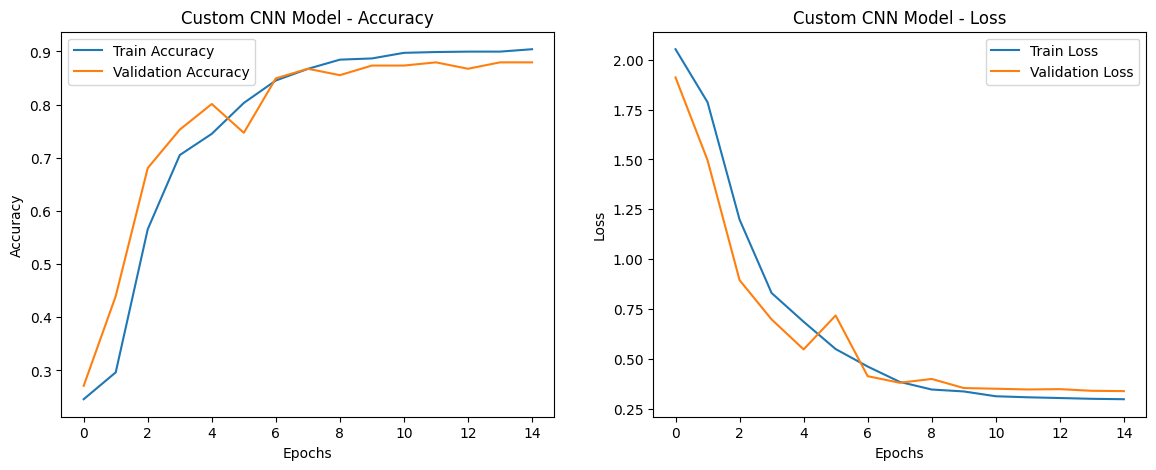

In [21]:
# Sonuc Grafigi
plt.figure(figsize=(14, 5))

# Doğruluk (Accuracy) Grafiği
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Custom CNN Model - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Kayıp (Loss) Grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Custom CNN Model - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step


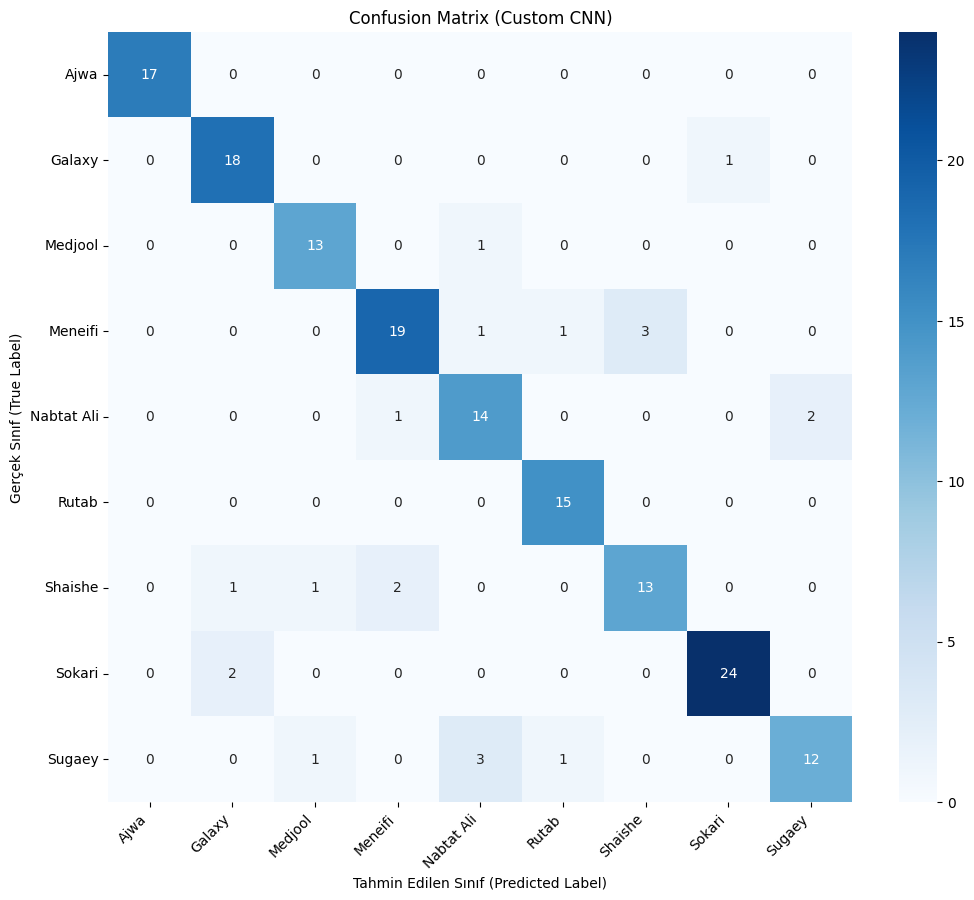


--- Sınıflandırma Raporu ---
              precision    recall  f1-score   support

        Ajwa       1.00      1.00      1.00        17
      Galaxy       0.86      0.95      0.90        19
     Medjool       0.87      0.93      0.90        14
     Meneifi       0.86      0.79      0.83        24
  Nabtat Ali       0.74      0.82      0.78        17
       Rutab       0.88      1.00      0.94        15
     Shaishe       0.81      0.76      0.79        17
      Sokari       0.96      0.92      0.94        26
      Sugaey       0.86      0.71      0.77        17

    accuracy                           0.87       166
   macro avg       0.87      0.88      0.87       166
weighted avg       0.88      0.87      0.87       166



In [22]:
from sklearn.metrics import confusion_matrix, classification_report

# 1. Tahminleri (Predictions) Alın
y_pred_probs = model.predict(test_data)
y_pred = np.argmax(y_pred_probs, axis=1) # En yüksek olasılığa sahip sınıf indeksini alın

# 2. Gerçek Etiketleri (True Labels) Alın
y_true = test_data.classes # Test verisindeki gerçek indeksler
class_labels = list(test_data.class_indices.keys()) # Sınıf isimleri

# Confusion Matrix'i hesaplayın
cm = confusion_matrix(y_true, y_pred)

# Matrisi görselleştirin
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, 
            yticklabels=class_labels)
plt.title('Confusion Matrix (Custom CNN)')
plt.ylabel('Gerçek Sınıf (True Label)')
plt.xlabel('Tahmin Edilen Sınıf (Predicted Label)')
plt.xticks(rotation=45, ha='right') # Etiketleri döndürme
plt.yticks(rotation=0)
plt.show()


# --- Sınıflandırma Raporu (Classification Report) ---
print("\n--- Sınıflandırma Raporu ---")
print(classification_report(y_true, y_pred, target_names=class_labels))